# マウナ・ロア気象観測所の$\mathsf{CO_2}$データ
- Python の vega_datasets というライブラリには，学習用の各種データセットが含まれている
- ここでは，その中からマウナ・ロア気象観測所の$\mathsf{CO_2}$データを時系列データとして利用する
- Date は日付 (西暦)，CO2 の単位は ppm (parts per million = 百万分率) である

※ このデータは局所的な大気変動の影響を受けにくい高高度で測定した大気中の$\mathsf{CO_2}$の  
　 データであって，マウナ・ロア山が排出する$\mathsf{CO_2}$のデータではない!!

※ 例によって，各コードの意味は理解しなくてもよい．何をしているのかをよく見ておくこと

In [1]:
# vega_datasets ライブラリから data モジュールをインポートする
from vega_datasets import data

# data モジュールから目的のデータを取得して，変数 co2 に代入する
co2 = data.co2_concentration()

# co2 の表示
co2

,Date,CO2,adjusted CO2
0,1958-03-01,315.70,314.44
1,1958-04-01,317.46,315.16
2,1958-05-01,317.51,314.71
3,1958-07-01,315.86,315.19
4,1958-08-01,314.93,316.19
...,...,...,...
736,2019-12-01,411.85,412.78
737,2020-01-01,413.37,413.32
738,2020-02-01,414.09,413.33
739,2020-03-01,414.51,412.94


### データの概観

In [ ]:
# グラフの表示のために，plotly.express ライブラリをインポートする
import plotly.express as px

# co2 の内容をグラフで表示
display(px.line(co2, x="Date", y="CO2"))

### 前処理

In [2]:
co2to000401 = co2.head(501)
co2to000401

,Date,CO2,adjusted CO2
0,1958-03-01,315.70,314.44
1,1958-04-01,317.46,315.16
2,1958-05-01,317.51,314.71
3,1958-07-01,315.86,315.19
4,1958-08-01,314.93,316.19
...,...,...,...
496,1999-12-01,368.00,368.88
497,2000-01-01,369.14,369.09
498,2000-02-01,369.46,368.75
499,2000-03-01,370.51,369.03


In [3]:
# 列 "adjusted CO2" の削除（元データに "adjusted CO2" の列がない場合は必要ない）
co2to000401.drop(columns="adjusted CO2", inplace=True)

# 列の名前の付け替え
co2to000401.rename(columns={"Date":"ds", "CO2":"y"}, inplace=True)

# 再表示
co2to000401

C:\Users\miura\AppData\Local\Temp\ipykernel_26956\1134185419.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  co2to000401.drop(columns="adjusted CO2", inplace=True)
C:\Users\miura\AppData\Local\Temp\ipykernel_26956\1134185419.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  co2to000401.rename(columns={"Date":"ds", "CO2":"y"}, inplace=True)


,ds,y
0,1958-03-01,315.70
1,1958-04-01,317.46
2,1958-05-01,317.51
3,1958-07-01,315.86
4,1958-08-01,314.93
...,...,...
496,1999-12-01,368.00
497,2000-01-01,369.14
498,2000-02-01,369.46
499,2000-03-01,370.51


### 将来予測
- Prophet モジュール (fbprophet) を使って，co2 の将来の推移を予測する
- Prophet モジュールは，STAN というベイズ統計モデルを扱うシステムを利用している
  - ベイズ統計モデルは過去の観測値から将来の値を確率的に推定するモデルである

In [4]:
# fbprophet ライブラリから Prophet モジュールをインポートする
from fbprophet import Prophet

# 新規に Prophet モデルを生成し，co2to000401 にフィッティングさせる
model = Prophet(weekly_seasonality=False, daily_seasonality=False)
model.fit(co2to000401)

# model の ds を480か月延長したデータフレームを生成して future に代入する
future = model.make_future_dataframe(periods=480, freq="M")

# 延長分の1日ズレを補正
from datetime import timedelta
future['ds'][501:] = future['ds'][501:] + timedelta(days=1)

# future の表示
future

c:\ProgramData\Miniconda3\lib\site-packages\fbprophet\forecaster.py:891: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)


,ds
0,1958-03-01
1,1958-04-01
2,1958-05-01
3,1958-07-01
4,1958-08-01
...,...
976,2039-12-01
977,2040-01-01
978,2040-02-01
979,2040-03-01


In [5]:
# future で延長した期間を model を用いて予測し，結果のデータフレームを forecast に代入する
forecast = model.predict(future)

# forecast の表示
forecast

c:\ProgramData\Miniconda3\lib\site-packages\fbprophet\forecaster.py:891: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)
c:\ProgramData\Miniconda3\lib\site-packages\fbprophet\forecaster.py:891: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1958-03-01,314.910598,315.693153,316.680910,314.910598,314.910598,1.292450,1.292450,1.292450,1.292450,1.292450,1.292450,0.0,0.0,0.0,316.203048
1,1958-04-01,314.985554,316.988962,318.030020,314.985554,314.985554,2.488636,2.488636,2.488636,2.488636,2.488636,2.488636,0.0,0.0,0.0,317.474190
2,1958-05-01,315.058092,317.480443,318.521556,315.058092,315.058092,2.958922,2.958922,2.958922,2.958922,2.958922,2.958922,0.0,0.0,0.0,318.017015
3,1958-07-01,315.205587,315.466901,316.487804,315.205587,315.205587,0.775828,0.775828,0.775828,0.775828,0.775828,0.775828,0.0,0.0,0.0,315.981415
4,1958-08-01,315.280543,313.537314,314.576425,315.280543,315.280543,-1.259726,-1.259726,-1.259726,-1.259726,-1.259726,-1.259726,0.0,0.0,0.0,314.020818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,2039-12-01,436.369971,349.067050,527.160610,350.647156,528.152979,-0.948667,-0.948667,-0.948667,-0.948667,-0.948667,-0.948667,0.0,0.0,0.0,435.421303
977,2040-01-01,436.513706,351.294547,528.391537,350.586221,528.786719,-0.016150,-0.016150,-0.016150,-0.016150,-0.016150,-0.016150,0.0,0.0,0.0,436.497556
978,2040-02-01,436.657441,351.254205,529.822481,350.525286,529.158824,0.611648,0.611648,0.611648,0.611648,0.611648,0.611648,0.0,0.0,0.0,437.269089
979,2040-03-01,436.791904,351.834719,531.107164,350.470379,529.613039,1.459368,1.459368,1.459368,1.459368,1.459368,1.459368,0.0,0.0,0.0,438.251272


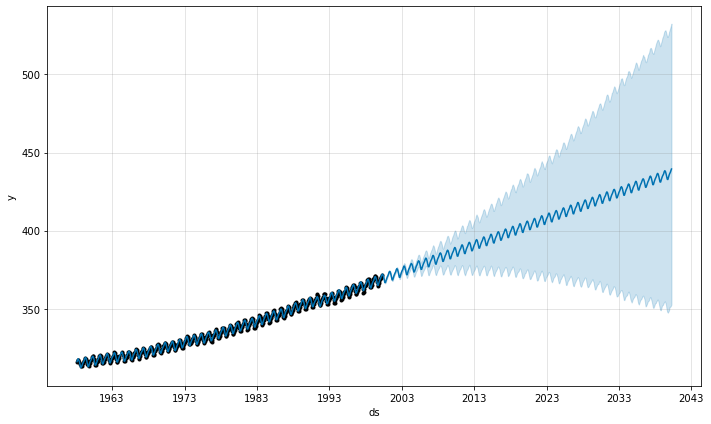

In [13]:
# forecast の予測値 (yhat) のグラフを表示する
# 黒いプロットは観測値
# 色付きの範囲は予測の上下限を表す (デフォルトでは80%信頼区間)
fig1 = model.plot(forecast)

c:\ProgramData\Miniconda3\lib\site-packages\fbprophet\forecaster.py:891: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)


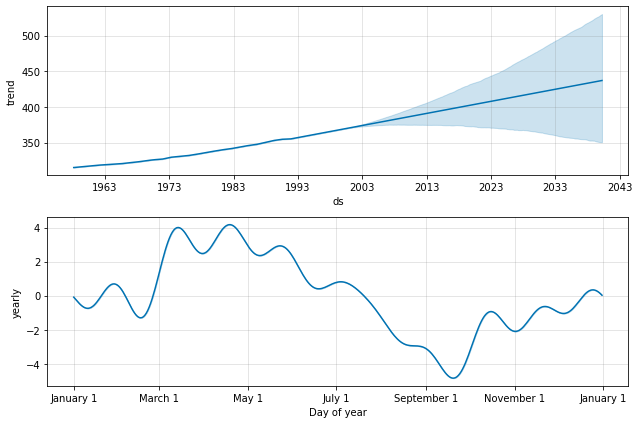

In [9]:
# 傾向変動 (trend) と季節変動 (yearly) のグラフを表示する
fig2 = model.plot_components(forecast)

In [10]:
# forecast のうち，値0の列と，yearly と同じ値の列を除き，並べ替えた列:
# (ds, trend, trend_lower, trend_upper, yhat, yhat_lower, yhat_upper, yearly)
# (日付, 傾向変動, …の下限, …の上限, 予測値, …の下限, …の上限, 季節変動)
# の dataframe を生成して forecast2 に代入

forecast2 = forecast[["ds", "trend", "trend_lower", "trend_upper", "yhat", "yhat_lower", "yhat_upper", "yearly"]]

# forecast2 の先頭10行 (1年分(6,10月欠損)) と末尾12行 (1年分) の表示
display(forecast2.head(10))
display(forecast2.tail(12))

,ds,trend,trend_lower,trend_upper,yhat,yhat_lower,yhat_upper,yearly
0,1958-03-01,314.910598,314.910598,314.910598,316.203048,315.693153,316.680910,1.292450
1,1958-04-01,314.985554,314.985554,314.985554,317.474190,316.988962,318.030020,2.488636
2,1958-05-01,315.058092,315.058092,315.058092,318.017015,317.480443,318.521556,2.958922
3,1958-07-01,315.205587,315.205587,315.205587,315.981415,315.466901,316.487804,0.775828
4,1958-08-01,315.280543,315.280543,315.280543,314.020818,313.537314,314.576425,-1.259726
5,1958-09-01,315.355500,315.355500,315.355500,312.249822,311.746794,312.750873,-3.105678
6,1958-11-01,315.502994,315.502994,315.502994,313.409894,312.894626,313.905522,-2.093100
7,1958-12-01,315.575533,315.575533,315.575533,314.616679,314.088695,315.139646,-0.958854
8,1959-01-01,315.650489,315.650489,315.650489,315.610952,315.118602,316.122229,-0.039537
9,1959-02-01,315.725445,315.725445,315.725445,316.320362,315.782959,316.811844,0.594916


,ds,trend,trend_lower,trend_upper,yhat,yhat_lower,yhat_upper,yearly
969,2039-05-01,435.377734,351.614785,525.163040,438.369215,354.814326,527.990539,2.991481
970,2039-06-01,435.521469,351.431839,525.548709,437.861130,353.795550,528.255826,2.339661
971,2039-07-01,435.660568,351.279483,525.918661,436.430107,352.297566,527.047693,0.769540
972,2039-08-01,435.804303,351.129512,526.300944,434.575328,349.491095,525.383138,-1.228974
973,2039-09-01,435.948038,350.979540,526.683227,432.855487,347.972627,523.929009,-3.092552
974,2039-10-01,436.087137,350.834407,527.053179,432.712148,347.488369,524.126592,-3.374989
975,2039-11-01,436.230872,350.706124,527.539683,434.141132,348.258854,525.325215,-2.089741
976,2039-12-01,436.369971,350.647156,528.152979,435.421303,349.067050,527.160610,-0.948667
977,2040-01-01,436.513706,350.586221,528.786719,436.497556,351.294547,528.391537,-0.016150
978,2040-02-01,436.657441,350.525286,529.158824,437.269089,351.254205,529.822481,0.611648


In [ ]:
forecast2.to_csv("co2Profet.csv", index=False)